##KISA 양성(피싱) 데이터 전처리##

KISA 양성(피싱) 데이터 전처리는 한국인터넷진흥원(KISA)에서 제공하는 피싱 사이트 데이터를 기반으로 수행함.
우선 URL 컬럼명을 통일하고 문자열 형식으로 변환한 뒤, URL 앞뒤 공백을 제거함. 데이터 내 URL 형식이 일관되지 않은 경우가 존재하므로 http://, https:// 스킴이 없는 URL에는 기본적으로 http://를 추가하여 형식을 통일함. 

URL을 기준으로 중복 데이터를 제거함. 피싱 데이터는 동일 URL이 여러 번 수집되는 경우가 많아 중복 제거를 수행하지 않으면 모델이 URL 패턴을 일반화하지 않고 암기하는 데이터 누수 문제가 발생할 수 있음.

전처리 이후 피싱 데이터에는 라벨을 추가함. 피싱 URL은 label=1로 정의함. 이후 모델 학습에 필요한 최소 정보만 유지하기 위해 url, label 컬럼만 남기고 불필요한 컬럼은 제거함.

최종적으로 전처리된 피싱 데이터는 phishing_clean.csv 형태로 저장함.


In [30]:
import pandas as pd

# 피싱 데이터 불러오기
phishing = pd.read_csv("한국인터넷진흥원_피싱사이트_20241231.csv",encoding="utf-8-sig")

# 컬럼명 변경
phishing = phishing.rename(
    columns={"홈페이지주소": "url","날짜": "date"})

# URL 정리
# 문자열 변환 + 공백 제거
phishing["url"] = (phishing["url"].astype(str).str.strip())

# http/https 없는 경우 보정
phishing["url"] = phishing["url"].apply(
    lambda x:
    x if x.startswith(("http://","https://"))
    else "http://" + x)


# URL 기준 중복 제거
before = len(phishing)

phishing = (phishing
    .drop_duplicates(subset=["url"])
    .reset_index(drop=True))

after = len(phishing)

print("중복 제거 전:", before)
print("중복 제거 후:", after)
print("제거된 개수:", before-after)


# 라벨 추가
phishing["label"] = 1


# 필요한 컬럼만
phishing = phishing[["url","label"]]

print("\n최종 피싱 데이터 개수:")
print(len(phishing))

display(phishing.sample(10,random_state=42))


# 저장
phishing.to_csv("phishing_clean.csv",index=False)
print("저장 완료: phishing_clean.csv")

중복 제거 전: 131752
중복 제거 후: 36664
제거된 개수: 95088

최종 피싱 데이터 개수:
36664


,url,label
6112,http://soi.googlemsgs.com/3CfE6i,1
10289,http://sib.o4he.bar,1
32080,http://han.gl/TxVJ3,1
22868,https://playstore045.esn9ds.online,1
17649,http://go9.co/URo,1
26448,http://buly.kr/uSUaZC,1
16155,https://mini-url.net/H0es,1
28679,https://tinyurl.com/hj66fg,1
11402,https://psce.pw/5msc39,1
13631,http://iz.ed5p.yachts,1


저장 완료: phishing_clean.csv


##Tranco 음성(정상) 데이터 전처리##

Tranco에서 제공하는 데이터는 실제 사용자 트래픽 기반의 상위 사이트 정보를 제공하지만, 상위 도메인이라 하더라도 모든 데이터가 일반적인 정상 사용자 사이트라고 보기 어렵다는 한계 존재.
예를 들어 CDN, DNS, 광고 서비스, 시스템 인프라용 도메인 등이 포함될 수 있으므로 추가적인 품질 검증 및 전처리가 필요함.

데이터 전처리 과정으로는 우선 결측치 및 중복 데이터를 제거. 
이후 정규표현식을 이용하여 정상적인 도메인 형식을 만족하지 않는 문자열을 제거함.
gtld-servers, cloudfront, doubleclick, akamai 등 실제 사용자가 직접 방문하는 일반 웹사이트가 아닌 네트워크 인프라 및 광고 관련 도메인을 제거하여 데이터의 순도를 향상시킴.

추가적으로 도메인 길이, 숫자 포함 비율, 하이픈 사용 개수 등을 기반으로 문자열 품질 필터링을 수행함. 지나치게 짧거나 긴 도메인, 숫자가 과도하게 포함된 도메인, 하이픈 사용 빈도가 높은 도메인은 일반적인 정상 사이트 특성과 차이가 있을 수 있으므로 제거함.
또한 무작위 문자열이 반복되는 형태의 도메인이나 도메인 판매, 광고성 목적, 비정상적인 패턴이 포함된 사이트 역시 제외함.

이후 공공기관, 교육기관, 연구기관, 의료기관, 글로벌 플랫폼, 기업 및 일반 서비스 사이트 등 신뢰도가 높은 사이트 패턴을 반영하기 위해 키워드 기반 필터링을 수행하였다. 사용된 주요 키워드는 gov, edu, university, hospital, research, google, github, microsoft, amazon, news, software, digital 등이며, 이를 기반으로 정상 사이트 후보군을 구축하였다. 필터링 결과 총 180035개의 정상 사이트 후보가 확보되었으며, 이후 피싱 데이터와의 데이터 균형을 위해 최종적으로 131,752개를 무작위 샘플링함. 

최종 데이터셋은 domain, url, label 컬럼으로 구성하였으며, URL 형태를 통일하기 위해 https:// 접두어를 추가하였다. 정상 데이터의 라벨은 0으로 지정하였으며, 이후 피싱 URL 데이터와 결합하여 최종 학습용 데이터셋 구축에 활용함.


In [63]:
# 데이터 확인
import pandas as pd

df = pd.read_csv("tranco_XWL8N.csv", header=None)
df.columns=['rank','domain']

print(df.shape)
df.head()

(1000000, 2)


,rank,domain
0,1,google.com
1,2,gtld-servers.net
2,3,cloudflare.com
3,4,gstatic.com
4,5,facebook.com


In [64]:
# 결측치 + 중복 제거
df=df.dropna()
df=df.drop_duplicates(subset=['domain'])

print(df.shape)

(1000000, 2)


In [65]:
# CDN, 광고, DNS 등 일반 URL 아닌 것 제거
infra_keywords = ['server','akadns','akamai','cloudfront','edgekey','doubleclick','googlesyndication','gstatic']

for k in infra_keywords:
    df=df[
        ~df['domain'].str.contains(k,case=False,na=False)]

In [67]:
# 형식 이상 제거
import re

pattern=r'^[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
df=df[df['domain'].str.match(pattern)]

# 지나치게 짧은 도메인 제거
df['domain_len']=(df['domain'].str.len())
df['domain_len'].describe()

df=df[(df['domain_len']>=6)&(df['domain_len']<=50)]

# 숫자 과다 제거
def digit_ratio(url):

    digit=sum(c.isdigit()for c in url)
    return digit/len(url)

df['digit_ratio']=(df['domain'].apply(digit_ratio))
df=df[df['digit_ratio']<0.3]

# 의심 키워드 제거
keywords=['login','verify','secure','update','account','bank','confirm','signin']

for w in keywords:
    df=df[
      ~df['domain'].str.contains(w,case=False,na=False)]

In [68]:
# URL 형태 만들기
df['url']=('https://'+df['domain'])

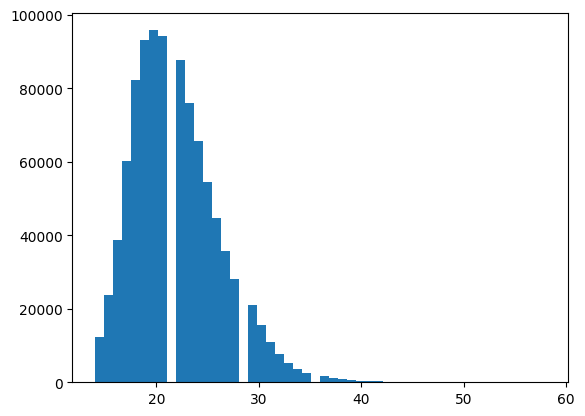

In [39]:
# 품질 점검 
import matplotlib.pyplot as plt

df['url_len']=(df['url'].apply(len))
df['url_len'].describe()

plt.hist(df['url_len'],bins=50)
plt.show()

In [40]:
# 너무 긴 도메인 확인
df[df['domain_len']>35][['domain']]

,domain
5926,14emeliaterracewestroxburyma02132.su
14668,aaronweintraubwantstobecyberpolice.com
15610,domain-is-4-sale-at-domainmarket.com
42640,hs-website-interactive-analytics.net
44062,cloudflare-terms-of-service-abuse.com
...,...
996472,golfedumorbihan-vannesagglomeration.bzh
996700,natyazhnye-potolki-nizhniy-novgorod-4.ru
997209,narkologicheskaya-klinika-podolsk9.ru
998385,institutomexicanodeultrasonido.com.mx


In [41]:
# 하이픈 개수 계산 및 하이픈이 너무 많은 도메인 제거
df["hyphen_count"] = df["domain"].str.count("-")
df = df[df["hyphen_count"] <= 2]


# 도메인 판매/오남용/의심 목적 키워드 제거
remove_words = ["4-sale","for-sale","forsale","domainmarket","domain-sale","buydomain","abuse","terms-of-service","cyberpolice"]

for w in remove_words:
    df = df[
        ~df["domain"].str.contains(w, case=False, na=False)]


# 정상 데이터 순도 높이기 위한 위험 TLD 제거
bad_tlds = [".su"]

for tld in bad_tlds:
    df = df[
        ~df["domain"].str.endswith(tld)]


# 숫자가 포함된 긴 도메인 제거
df = df[
    ~((df["domain_len"] > 35) &(df["domain"].str.contains(r"\d", regex=True)))]


# 다시 도메인 길이/하이픈 컬럼 재계산
df["domain_len"] = df["domain"].str.len()
df["hyphen_count"] = df["domain"].str.count("-")


# 추가 전처리 후 확인
print("추가 전처리 후 데이터 개수:", len(df))
print("\n아직 긴 도메인 확인:")
display(
    df[df["domain_len"] > 35][["domain", "domain_len", "hyphen_count"]].head(30))

추가 전처리 후 데이터 개수: 962234

아직 긴 도메인 확인:


,domain,domain_len,hyphen_count
45680,gestionsecretariasdeeducacion.gov.co,36,0
134677,ttjmemnvpdsmcfvnmdkvmsdfvlefnslsdeakfnek.click,46,0
195501,childrensmiraclenetworkhospitals.org,36,0
211961,consadole-digitalcard-collection.com,36,2
211978,corporacioneducativavirtualecuador.com,38,0
214433,portaldoempreendedorgoiano.go.gov.br,36,0
236481,verwaltungsvorschriften-im-internet.de,38,2
239709,universaldestinationsandexperiences.com,39,0
241399,poltekkesmandalawaluya-kendari.ac.id,36,1
243776,acquistalapatentediguidasenzaesame.com,38,0


In [42]:
import re

# 랜덤 문자열 의심 함수
def suspicious_random(domain):
    # TLD 제거
    name = domain.split('.')[0]

    # 모음 개수
    vowels = sum(c in 'aeiou' for c in name.lower())

    # 모음 비율
    vowel_ratio = vowels / max(len(name),1)

    # 너무 긴데 모음 거의 없음
    if len(name)>25 and vowel_ratio<0.15:
        return True

    # 자음 과다 반복
    if re.search(r'[bcdfghjklmnpqrstvwxyz]{8,}',name.lower()):
        return True

    return False


df['random_flag']=df['domain'].apply(
    suspicious_random
)

df=df[
    df['random_flag']==False
]

print("랜덤 문자열 제거 후:",len(df))

display(
    df[df['domain_len']>35][
        ['domain']
    ].head(30)
)

랜덤 문자열 제거 후: 961007


,domain
45680,gestionsecretariasdeeducacion.gov.co
195501,childrensmiraclenetworkhospitals.org
211961,consadole-digitalcard-collection.com
211978,corporacioneducativavirtualecuador.com
214433,portaldoempreendedorgoiano.go.gov.br
236481,verwaltungsvorschriften-im-internet.de
239709,universaldestinationsandexperiences.com
241399,poltekkesmandalawaluya-kendari.ac.id
243776,acquistalapatentediguidasenzaesame.com
249263,internationaljournalofcardiology.com


In [44]:
trusted_keywords = [

    # 공공/교육
    "gov",
    "edu",
    "ac",
    "school",
    "college",
    "university",
    "library",
    "museum",
    "research",
    "institute",
    "academy",

    # 의료
    "hospital",
    "clinic",
    "medical",
    "health",
    "pharma",

    # 학술
    "journal",
    "science",
    "publication",

    # 글로벌 플랫폼
    "google",
    "youtube",
    "github",
    "microsoft",
    "apple",
    "amazon",
    "facebook",
    "meta",
    "linkedin",
    "wikipedia",
    "wordpress",

    # 국내
    "naver",
    "kakao",
    "daum",
    "coupang",

    # 기업/기관
    "group",
    "company",
    "official",
    "association",
    "foundation",
    "organization",
    "service",
    "systems",

    # 일반 서비스
    "news",
    "media",
    "travel",
    "hotel",
    "air",
    "shop",
    "store",
    "market",
    "finance",
    "bank",

    # 국가/지역
    "city",
    "state",
    "municipal"
]

pattern='|'.join(trusted_keywords)

trusted=df[
    df['domain'].str.contains(
        pattern,
        case=False,
        na=False
    )
].copy()

print("후보 개수:",len(trusted))

display(
    trusted.sample(
        30,
        random_state=42
    )[['domain']]
)

후보 개수: 125898


,domain
619434,inpeaceapp.com
266968,markmywordsmedia.com
126669,citytimezone.com
746049,gncgroup.be
882359,cardiachill.com
273826,fantasiastore.it
343431,udv.group
312029,sylvania-group.com
118445,gacorbos88it.com
206260,proshop.nl


In [45]:
target_n = 36664

# 샘플링
normal = trusted.sample(
    n=target_n,
    random_state=42
).copy()

# URL 생성
normal['url'] = 'https://' + normal['domain']

# 정상 라벨
normal['label'] = 0

# 인덱스 초기화
normal = normal.reset_index(drop=True)

# 필요한 컬럼만 유지
normal = normal[
    ['domain', 'url', 'label']
]

# 중복 최종 확인 (안전용)
normal = normal.drop_duplicates(
    subset=['url']
)

print("최종 정상 데이터 개수:", len(normal))

display(
    normal.sample(
        20,
        random_state=42
    )
)

# 저장
normal.to_csv(
    "normal_clean.csv",
    index=False
)

print("저장 완료: normal_clean.csv")

최종 정상 데이터 개수: 36664


,domain,url,label
6112,smartcasinomarket.com,https://smartcasinomarket.com,0
10289,financeasia.com,https://financeasia.com,0
32080,365datacenters.com,https://365datacenters.com,0
22868,optimize.health,https://optimize.health,0
17649,thefoodieaffair.com,https://thefoodieaffair.com,0
26448,clearblackjackstation.nl,https://clearblackjackstation.nl,0
16155,tasheelfinance.com,https://tasheelfinance.com,0
28679,njau.edu.cn,https://njau.edu.cn,0
11402,waca.tw,https://waca.tw,0
13631,mitos.gov.gr,https://mitos.gov.gr,0


저장 완료: normal_clean.csv


##최종 학습 데이터셋 구성##

최종 학습 데이터셋 구축 단계에서는 전처리가 완료된 정상 URL 데이터(normal_clean.csv)와 피싱 URL 데이터(phishing_clean.csv)를 결합하여 모델 학습용 데이터셋을 생성함. 두 데이터는 url, label 컬럼만 사용하였으며, 이후 하나의 데이터프레임으로 병합한 뒤 학습 과정에서 데이터 순서에 따른 영향을 제거하기 위해 무작위 셔플을 수행함.

이후 URL 문자열 자체를 머신러닝 모델에 직접 입력하지 않고, URL 구조에서 피싱 여부와 관련된 특징을 추출하는 Feature Engineering 과정을 수행함. URL은 urlparse()를 이용해 도메인(domain), 경로(path), 쿼리(query) 영역으로 분리하였으며, URL 구조적 특성을 수치화.

길이 기반 특징으로는 URL 전체 길이(url_length), 도메인 길이(domain_length), 경로 길이(path_length), 쿼리 문자열 길이(query_length)를 추출함. 피싱 URL은 정상 URL 대비 비정상적으로 길거나 복잡한 구조를 가지는 경우가 많기 때문에 URL 길이는 중요한 판별 요소로 활용.

숫자 및 특수문자 기반 특징도 생성하였다. 숫자 개수(num_digits)와 URL 전체 길이 대비 숫자 비율(digit_ratio)을 계산하였으며, URL 내 특수문자의 사용 패턴을 분석하기 위해 점(.), 슬래시(/), 하이픈(-), 골뱅이(@), 물음표(?), 앰퍼샌드(&) 개수를 각각 추출함. 전체 특수문자 개수(num_special_chars)를 계산.
피싱 URL은 난독화 목적 또는 복잡한 URL 구조 생성을 위해 숫자와 특수문자를 과도하게 사용하는 경향이 있어 주요 특징으로 활용.

도메인 구조로는 도메인 내 점(.) 개수를 기반으로 서브도메인 개수(subdomain_count)를 계산하였고, 최상위 도메인(TLD)의 길이(tld_length)를 추출함. 또한 국제화 도메인 공격(IDN) 탐지를 위해 xn-- 문자열 포함 여부(has_punycode)를 생성.

login, verify, update, secure, account 등의 키워드가 URL에 포함되는지 확인하여 has_suspicious_keyword 변수를 생성. 

| 키워드       | 의미    | 피싱에서 많이 쓰는 이유  |
| --------- | ----- | -------------- |
| `login`   | 로그인   | 로그인 유도 페이지 사칭  |
| `verify`  | 인증/확인 | 계정 인증 필요하다고 속임 |
| `update`  | 업데이트  | 정보 갱신 요구       |
| `secure`  | 보안    | 안전한 사이트처럼 위장   |
| `account` | 계정    | 계정 확인/복구 유도    |


보안 관련 특징으로 HTTPS 사용 여부(has_https)와 IP 주소 직접 사용 여부(has_ip)를 생성함. 일반적으로 피싱 사이트는 HTTPS 적용 비율이 낮거나 도메인 대신 IP 주소를 직접 사용하는 경우가 존재하므로 피싱 판별에 도움이 되는 특징으로 활용.

최종적으로 URL 원문, 추출된 Feature, 라벨 정보를 포함하는 final_url_dataset.csv를 생성하였으며, 이후 Logistic Regression, Random Forest, XGBoost 모델 학습에 활용.

| 컬럼명 | 설명 |
| --- | --- |
| `url` | 원본 URL 문자열 |
| `url_length` | URL 전체 문자열 길이 |
| `domain_length` | 도메인(domain) 길이 |
| `path_length` | URL 경로(path) 길이 |
| `query_length` | URL 쿼리(query) 길이 |
| `num_digits` | URL 내 숫자 개수 |
| `digit_ratio` | URL 전체 길이 대비 숫자 비율 |
| `num_dots` | `.` 개수 |
| `num_slashes` | `/` 개수 |
| `num_hyphens` | `-` 개수 |
| `num_at` | `@` 개수 |
| `num_question_marks` | `?` 개수 |
| `num_ampersand` | `&` 개수 |
| `num_special_chars` | 전체 특수문자 개수 |
| `subdomain_count` | 서브도메인 개수 |
| `tld_length` | 최상위 도메인(TLD) 길이 |
| `has_punycode` | `xn--` 포함 여부 (포함=1, 미포함=0) |
| `has_suspicious_keyword` | 의심 키워드(login, verify 등) 포함 여부 |
| `has_https` | HTTPS 사용 여부 (`https=1`) |
| `has_ip` | IP 주소 직접 사용 여부 |
| `label` | 클래스 라벨 (정상=0, 피싱=1) |

In [54]:
import pandas as pd
from urllib.parse import urlparse
import re

# 데이터 불러오기
normal = pd.read_csv("normal_clean.csv")
phishing = pd.read_csv("phishing_clean.csv")

normal = normal[["url", "label"]]
phishing = phishing[["url", "label"]]

# 데이터 결합 및 셔플
df = pd.concat([normal, phishing], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("라벨 개수 확인")
print(df["label"].value_counts())

# Feature 추출 함수
keywords = ["login", "verify", "update", "secure", "account"]

def extract_features(url):
    parsed = urlparse(url)

    domain = parsed.netloc
    path = parsed.path
    query = parsed.query

    if domain == "":
        domain = parsed.path.split("/")[0]

    tld = domain.split(".")[-1] if "." in domain else ""

    num_digits = sum(c.isdigit() for c in url)

    return {
        # 길이/구성
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "query_length": len(query),

        # 숫자
        "num_digits": num_digits,
        "digit_ratio": num_digits / len(url) if len(url) > 0 else 0,

        # 주요 특수문자 개수
        "num_dots": url.count("."),
        "num_slashes": url.count("/"),
        "num_hyphens": url.count("-"),
        "num_at": url.count("@"),
        "num_question_marks": url.count("?"),
        "num_ampersand": url.count("&"),

        # 전체 특수문자 수
        "num_special_chars": len(
            re.findall(r"[^a-zA-Z0-9]", url)
        ),

        # 도메인 구조
        "subdomain_count": max(domain.count(".") - 1, 0),
        "tld_length": len(tld),
        "has_punycode": int("xn--" in domain),

        # 의심 키워드
        "has_suspicious_keyword": int(
            any(k in url.lower() for k in keywords)
        ),

        # 스킴/보안
        "has_https": int(parsed.scheme == "https"),
        "has_ip": int(
            bool(re.search(r"(\d{1,3}\.){3}\d{1,3}", domain))
        )
    }

# Feature 생성
features = pd.DataFrame(
    df["url"].apply(extract_features).tolist()
)

# 원본 url + feature + label 합치기
final_df = pd.concat(
    [
        df[["url"]].reset_index(drop=True),
        features.reset_index(drop=True),
        df[["label"]].reset_index(drop=True)
    ],
    axis=1
)

# 최종 확인
print("최종 데이터 크기:", final_df.shape)
print("라벨 분포:")
print(final_df["label"].value_counts())

display(final_df.head())

# 저장
final_df.to_csv("final_url_dataset.csv", index=False)

print("저장 완료: final_url_dataset.csv")

라벨 개수 확인
label
0    36664
1    36664
Name: count, dtype: int64
최종 데이터 크기: (73328, 21)
라벨 분포:
label
0    36664
1    36664
Name: count, dtype: int64


,url,url_length,domain_length,path_length,query_length,num_digits,digit_ratio,num_dots,num_slashes,num_hyphens,...,num_question_marks,num_ampersand,num_special_chars,subdomain_count,tld_length,has_punycode,has_suspicious_keyword,has_https,has_ip,label
0,https://iteach4u.kr,19,11,0,0,1,0.052632,1,2,0,...,0,0,4,0,2,0,0,1,0,0
1,http://gov.i9gu.rest,20,13,0,0,1,0.050000,2,2,0,...,0,0,5,1,4,0,0,0,0,1
2,https://lacollection.io,23,15,0,0,0,0.000000,1,2,0,...,0,0,4,0,2,0,0,1,0,0
3,https://stoic-media.com,23,15,0,0,0,0.000000,1,2,1,...,0,0,5,0,3,0,0,1,0,0
4,http://nal.la/bbbv_w,20,6,7,0,0,0.000000,1,3,0,...,0,0,6,0,2,0,0,0,0,1


저장 완료: final_url_dataset.csv


In [55]:
# 결측치 확인

print(final_df.isnull().sum())

url                       0
url_length                0
domain_length             0
path_length               0
query_length              0
num_digits                0
digit_ratio               0
num_dots                  0
num_slashes               0
num_hyphens               0
num_at                    0
num_question_marks        0
num_ampersand             0
num_special_chars         0
subdomain_count           0
tld_length                0
has_punycode              0
has_suspicious_keyword    0
has_https                 0
has_ip                    0
label                     0
dtype: int64


In [47]:
# 결측치 확인

print(final_df.isnull().sum())

url                       0
url_length                0
domain_length             0
path_length               0
query_length              0
num_digits                0
num_dots                  0
num_hyphens               0
num_at                    0
num_special_chars         0
subdomain_count           0
tld_length                0
has_punycode              0
has_suspicious_keyword    0
has_https                 0
has_ip                    0
label                     0
dtype: int64


In [56]:
# 중복 확인

print("URL 중복:", final_df["url"].duplicated().sum())

URL 중복: 0


In [57]:
# 라벨 균형

print(final_df["label"].value_counts())

label
0    36664
1    36664
Name: count, dtype: int64


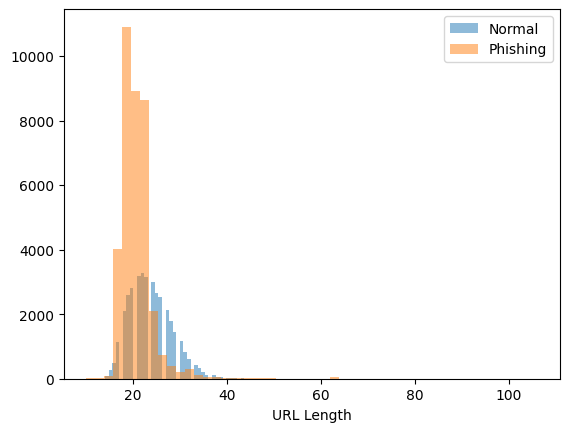

In [58]:
# Feature 분포 길이

import matplotlib.pyplot as plt

plt.hist(
    final_df[final_df['label']==0]['url_length'],
    alpha=0.5,
    bins=50
)

plt.hist(
    final_df[final_df['label']==1]['url_length'],
    alpha=0.5,
    bins=50
)

plt.legend(['Normal','Phishing'])

plt.xlabel('URL Length')
plt.show()

In [59]:
# 상관관계 확인

corr = final_df.drop(
    ['url'],
    axis=1
).corr()

print(
corr['label']
.sort_values(
ascending=False
))

label                     1.000000
num_slashes               0.640474
path_length               0.602304
digit_ratio               0.570259
num_special_chars         0.562843
num_digits                0.449057
num_dots                  0.194290
subdomain_count           0.191281
num_question_marks        0.055621
query_length              0.053062
tld_length                0.049925
has_ip                    0.044819
has_punycode              0.029053
has_suspicious_keyword    0.008258
num_ampersand             0.007386
num_at                    0.003693
num_hyphens              -0.073235
url_length               -0.333197
domain_length            -0.576753
has_https                -0.756447
Name: label, dtype: float64
